In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/hadjerhamaidi/date-palm-data/Date Palm data/brown spots/brownspots-132.jpg
/kaggle/input/datasets/hadjerhamaidi/date-palm-data/Date Palm data/brown spots/brownspots-308.jpg
/kaggle/input/datasets/hadjerhamaidi/date-palm-data/Date Palm data/brown spots/brownspots-292.jpg
/kaggle/input/datasets/hadjerhamaidi/date-palm-data/Date Palm data/brown spots/brownspots-325.jpg
/kaggle/input/datasets/hadjerhamaidi/date-palm-data/Date Palm data/brown spots/brownspots-373.jpg
/kaggle/input/datasets/hadjerhamaidi/date-palm-data/Date Palm data/brown spots/brownspots-148.jpg
/kaggle/input/datasets/hadjerhamaidi/date-palm-data/Date Palm data/brown spots/brownspots-251.jpg
/kaggle/input/datasets/hadjerhamaidi/date-palm-data/Date Palm data/brown spots/brownspots-438.jpg
/kaggle/input/datasets/hadjerhamaidi/date-palm-data/Date Palm data/brown spots/brownspots-390.jpg
/kaggle/input/datasets/hadjerhamaidi/date-palm-data/Date Palm data/brown spots/brownspots-38.jpg
/kaggle/input/dataset

In [22]:
import os

import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.applications.efficientnet import preprocess_input
import numpy as np

In [23]:
# ── Dataset path ──────────────────────────────────────────────────────────────
dataset_path = "/kaggle/input/datasets/hadjerhamaidi/date-palm-data/Date Palm data"

total_images = 0
class_counts = {}

for class_name in os.listdir(dataset_path):
    class_path = os.path.join(dataset_path, class_name)
    if os.path.isdir(class_path):
        num_images = len(os.listdir(class_path))
        class_counts[class_name] = num_images
        total_images += num_images

print("Total Images:", total_images)
print("\nImages per class:")
for cls, count in class_counts.items():
    print(f"  {cls}: {count}")

Total Images: 2631

Images per class:
  brown spots: 470
  healthy: 1203
  white scale: 958


In [61]:
IMG_SIZE = (224, 224)   # EfficientNet works great with 224
BATCH_SIZE = 32

In [67]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,  # 🔥 IMPORTANT
    shear_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.7, 1.3],
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.3,
    rotation_range=35,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
        shuffle=False   

)

Found 2106 images belonging to 3 classes.
Found 525 images belonging to 3 classes.


In [85]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)

class_weights = dict(enumerate(class_weights))

In [86]:
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

In [87]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(train_generator.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

In [88]:
for layer in base_model.layers:
    layer.trainable = False

In [89]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.03),
    metrics=['accuracy']
)

In [90]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6
)

In [91]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weights
)

Epoch 1/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 79s 896ms/step - accuracy: 0.5539 - loss: 0.9693 - val_accuracy: 0.8705 - val_loss: 0.5705 - learning_rate: 1.0000e-04
Epoch 2/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 35s 530ms/step - accuracy: 0.8434 - loss: 0.4559 - val_accuracy: 0.9524 - val_loss: 0.3617 - learning_rate: 1.0000e-04
Epoch 3/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 36s 546ms/step - accuracy: 0.9124 - loss: 0.3324 - val_accuracy: 0.8838 - val_loss: 0.3762 - learning_rate: 1.0000e-04
Epoch 4/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 35s 529ms/step - accuracy: 0.9325 - loss: 0.2780 - val_accuracy: 0.9257 - val_loss: 0.3356 - learning_rate: 1.0000e-04
Epoch 5/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 35s 532ms/step - accuracy: 0.9512 - loss: 0.2521 - val_accuracy: 0.9029 - val_loss: 0.3379 - learning_rate: 1.0000e-04
Epoch 6/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 35s 531ms/step - accuracy: 0.9469 - loss: 0.2492 - val_accuracy: 0.9429 - val_loss: 0.2938 - learning_rate: 1.0000e-04
Epoch 7/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 35s 535ms/step - acc

In [92]:
for layer in base_model.layers:
    layer.trainable = False

for layer in base_model.layers[-40:]:
    layer.trainable = True

In [93]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    metrics=['accuracy']
)

In [94]:
history_fine = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weights
)

Epoch 1/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 88s 922ms/step - accuracy: 0.6998 - loss: 0.6201 - val_accuracy: 0.9219 - val_loss: 0.3543 - learning_rate: 1.0000e-05
Epoch 2/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 34s 522ms/step - accuracy: 0.8806 - loss: 0.4337 - val_accuracy: 0.9314 - val_loss: 0.3876 - learning_rate: 1.0000e-05
Epoch 3/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 35s 530ms/step - accuracy: 0.9076 - loss: 0.3787 - val_accuracy: 0.9295 - val_loss: 0.3980 - learning_rate: 1.0000e-05
Epoch 4/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 35s 530ms/step - accuracy: 0.9344 - loss: 0.3456 - val_accuracy: 0.9200 - val_loss: 0.3945 - learning_rate: 1.0000e-05
Epoch 5/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 35s 529ms/step - accuracy: 0.9561 - loss: 0.3121 - val_accuracy: 0.9448 - val_loss: 0.3864 - learning_rate: 5.0000e-06
Epoch 6/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 35s 529ms/step - accuracy: 0.9559 - loss: 0.2984 - val_accuracy: 0.9429 - val_loss: 0.3698 - learning_rate: 5.0000e-06


In [95]:
import numpy as np
val_generator.reset()

# Get predictions
y_pred = model.predict(val_generator)
y_pred_classes = np.argmax(y_pred, axis=1)

# True labels
y_true = val_generator.classes


17/17 ━━━━━━━━━━━━━━━━━━━━ 19s 764ms/step


In [96]:
from sklearn.metrics import classification_report, accuracy_score

print("Accuracy:", accuracy_score(y_true, y_pred_classes))
print(classification_report(y_true, y_pred_classes, target_names=list(val_generator.class_indices.keys())))

Accuracy: 0.9428571428571428
              precision    recall  f1-score   support

 brown spots       1.00      0.97      0.98        94
     healthy       0.99      0.89      0.94       240
 white scale       0.87      0.99      0.93       191

    accuracy                           0.94       525
   macro avg       0.95      0.95      0.95       525
weighted avg       0.95      0.94      0.94       525



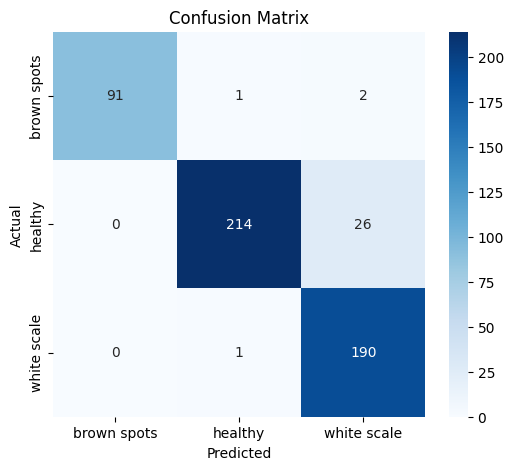

In [99]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=val_generator.class_indices.keys(),
            yticklabels=val_generator.class_indices.keys())

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [103]:
acc = history.history['accuracy'] + history_fine.history['accuracy']
val_acc = history.history['val_accuracy'] + history_fine.history['val_accuracy']

loss = history.history['loss'] + history_fine.history['loss']
val_loss = history.history['val_loss'] + history_fine.history['val_loss']
acc = history.history['accuracy'] + history_fine.history['accuracy']
print(acc)

[0.6737892031669617, 0.8741690516471863, 0.9121557474136353, 0.9320987462997437, 0.9415954351425171, 0.9558404684066772, 0.9501424431800842, 0.9610636234283447, 0.9643874764442444, 0.9705603122711182, 0.9700854420661926, 0.9757834672927856, 0.9738841652870178, 0.7435897588729858, 0.8898385763168335, 0.9202279448509216, 0.9415954351425171, 0.9496676325798035, 0.954890787601471]


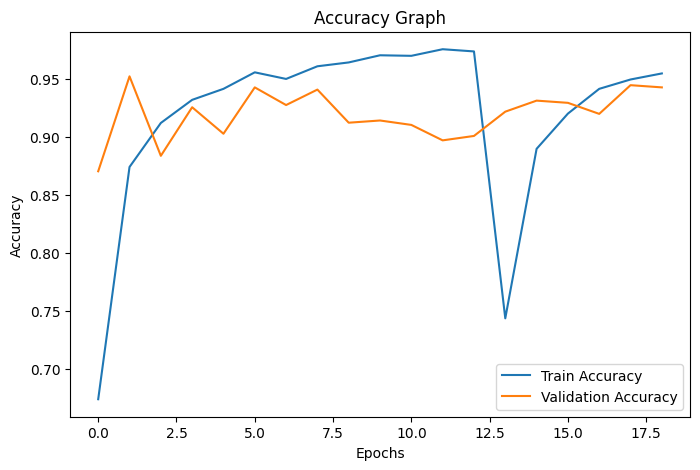

In [108]:
plt.figure(figsize=(8,5))
plt.plot(acc, label='Train Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.title('Accuracy Graph')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

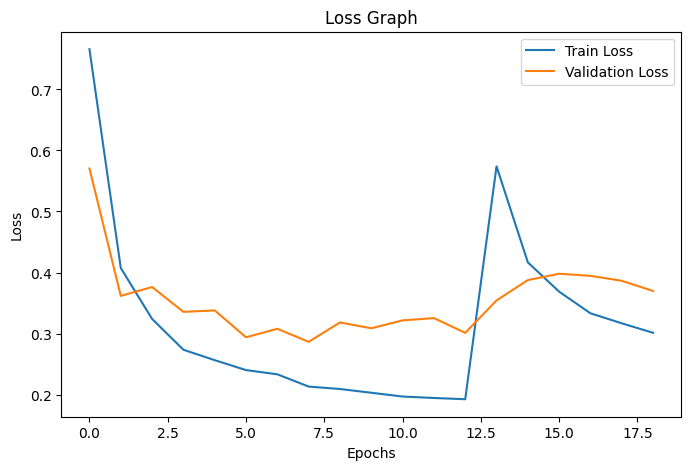

In [105]:
plt.figure(figsize=(8,5))
plt.plot(loss, label='Train Loss')
plt.plot(val_loss, label='Validation Loss')
plt.title('Loss Graph')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()